In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Define the grid-world environment
class GridWorld:
    def __init__(self, grid_size, terminal_states, rewards, actions, gamma=0.9):
        self.grid_size = grid_size
        self.terminal_states = terminal_states
        self.rewards = rewards
        self.actions = actions
        self.gamma = gamma  # Discount factor

    def is_terminal(self, state):
        return state in self.terminal_states

    def step(self, state, action):
        if self.is_terminal(state):
            return state, 0
        next_state = (state[0] + action[0], state[1] + action[1])
        if next_state[0] < 0 or next_state[0] >= self.grid_size or next_state[1] < 0 or next_state[1] >= self.grid_size:
            next_state = state
        reward = self.rewards.get(next_state, -1)  # Default reward for non-terminal states
        return next_state, reward

In [17]:
# Policy Evaluation
def policy_evaluation(env, policy, theta=1e-6):
    grid_size = env.grid_size
    V = np.zeros((grid_size, grid_size))  # Initialize value function
    while True:
        delta = 0
        for i in range(grid_size):
            for j in range(grid_size):
                state = (i, j)
                if env.is_terminal(state):
                    continue
                v = V[state]
                V[state] = 0
                for action in env.actions:
                    next_state, reward = env.step(state, action)
                    V[state] += policy[state][action] * (reward + env.gamma * V[next_state])
                delta = max(delta, abs(v - V[state]))
        if delta < theta:
            break
    return V

In [18]:
# Value Iteration
def value_iteration(env, theta=1e-6):
    grid_size = env.grid_size
    V = np.zeros((grid_size, grid_size))  # Initialize value function
    while True:
        delta = 0
        for i in range(grid_size):
            for j in range(grid_size):
                state = (i, j)
                if env.is_terminal(state):
                    continue
                v = V[state]
                # Compute the maximum value over all actions
                action_values = []
                for action in env.actions:
                    next_state, reward = env.step(state, action)
                    action_values.append(reward + env.gamma * V[next_state])
                V[state] = max(action_values)
                delta = max(delta, abs(v - V[state]))
        if delta < theta:
            break
    # Derive the optimal policy
    policy = {}
    for i in range(grid_size):
        for j in range(grid_size):
            state = (i, j)
            if env.is_terminal(state):
                policy[state] = {a: 0 for a in env.actions}  # No action in terminal states
                continue
            action_values = {}
            for action in env.actions:
                next_state, reward = env.step(state, action)
                action_values[action] = reward + env.gamma * V[next_state]
            best_action = max(action_values, key=action_values.get)
            policy[state] = {a: 1 if a == best_action else 0 for a in env.actions}
    return V, policy

In [19]:
# Visualization functions
def plot_grid_world(env, title="Grid World"):
    grid_size = env.grid_size
    grid = np.zeros((grid_size, grid_size))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid, cmap="Greys", origin="upper")
    # Mark terminal states
    for state in env.terminal_states:
        plt.text(state[1], state[0], "T", ha="center", va="center", color="red", fontsize=16)
    # Add rewards
    for state, reward in env.rewards.items():
        if not env.is_terminal(state):
            plt.text(state[1], state[0], f"R={reward}", ha="center", va="center", color="blue", fontsize=12)
    plt.title(title)
    plt.show()

def plot_value_function(V, title="Value Function"):
    plt.figure(figsize=(6, 6))
    plt.imshow(V, cmap="viridis", origin="upper")
    plt.colorbar(label="Value")
    plt.title(title)
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            plt.text(j, i, f"{V[i, j]:.2f}", ha="center", va="center", color="white")
    plt.show()

def plot_policy(policy, grid_size, title="Policy"):
    action_map = {(-1, 0): "↑", (1, 0): "↓", (0, -1): "←", (0, 1): "→"}
    policy_grid = np.empty((grid_size, grid_size), dtype=str)
    for i in range(grid_size):
        for j in range(grid_size):
            state = (i, j)
            if env.is_terminal(state):
                policy_grid[i, j] = "T"
            else:
                best_action = max(policy[state], key=policy[state].get)
                policy_grid[i, j] = action_map[best_action]
    plt.figure(figsize=(6, 6))
    plt.imshow(np.zeros((grid_size, grid_size)), cmap="gray", origin="upper")
    for i in range(grid_size):
        for j in range(grid_size):
            plt.text(j, i, policy_grid[i, j], ha="center", va="center", color="red", fontsize=16)
    plt.title(title)
    plt.show()

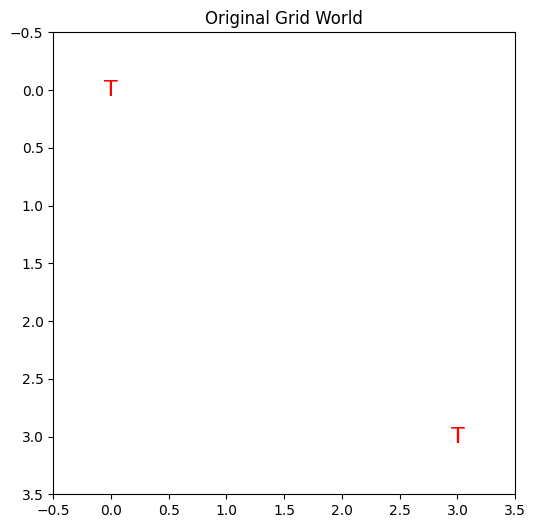

Policy Evaluation - Value Function:
[[ 0.         -2.47312738 -3.34844969 -3.26801538]
 [-2.84313492 -4.30989528 -4.69641221 -4.26793296]
 [-3.87177783 -4.69797222 -4.50222147 -3.27977381]
 [-3.33277176 -3.75153815 -2.89127088  0.        ]]


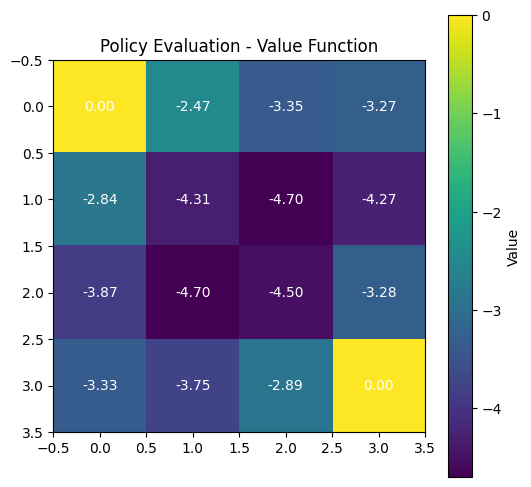


Value Iteration - Optimal Value Function:
[[ 0.   0.  -1.  -1.9]
 [ 0.  -1.  -1.9 -1. ]
 [-1.  -1.9 -1.   0. ]
 [-1.9 -1.   0.   0. ]]


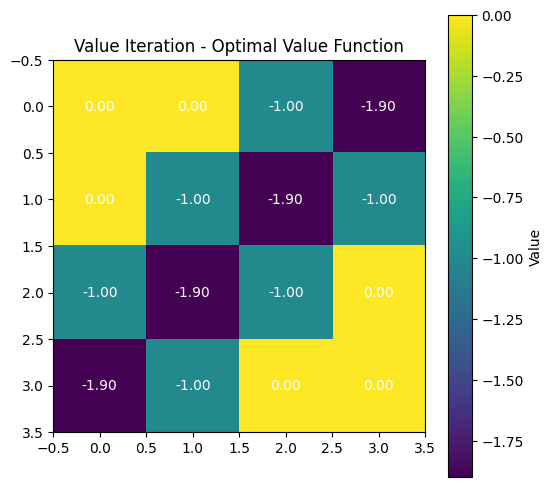

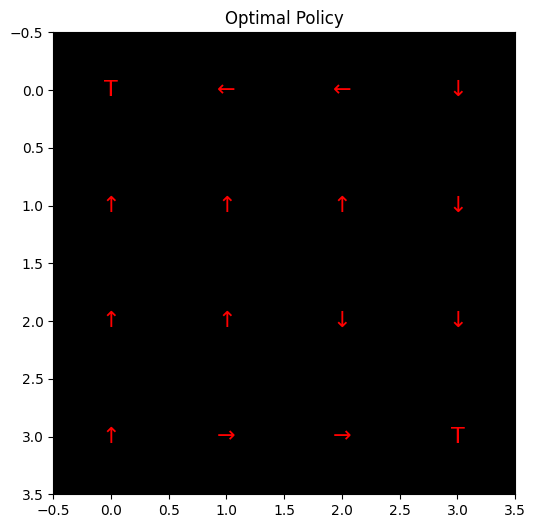

In [20]:
# Example usage
if __name__ == "__main__":
    grid_size = 4
    terminal_states = [(0, 0), (grid_size - 1, grid_size - 1)]
    rewards = {(0, 0): 0, (grid_size - 1, grid_size - 1): 0}  # Terminal states have 0 reward
    actions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right
    env = GridWorld(grid_size, terminal_states, rewards, actions)

    # Visualize the original grid world
    plot_grid_world(env, title="Original Grid World")

    # Policy Evaluation
    policy = {state: {action: 0.25 for action in actions} for state in [(i, j) for i in range(grid_size) for j in range(grid_size)]}
    V = policy_evaluation(env, policy)
    print("Policy Evaluation - Value Function:")
    print(V)
    plot_value_function(V, title="Policy Evaluation - Value Function")

    # Value Iteration
    V_opt, policy_opt = value_iteration(env)
    print("\nValue Iteration - Optimal Value Function:")
    print(V_opt)
    plot_value_function(V_opt, title="Value Iteration - Optimal Value Function")
    plot_policy(policy_opt, grid_size, title="Optimal Policy")